<a href="https://colab.research.google.com/github/akashvgeorge/ICT_DSA_26/blob/main/unsupervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Loading Data

In [2]:
data = pd.read_csv("/content/drive/MyDrive/ICT/adult_dataset.csv")

In [3]:
len(data)

48842

In [4]:
data.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [6]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


# Data Preprocessing and EDA

## Handling duplicates

In [7]:
data.duplicated().sum()

np.int64(16)

In [8]:
data = data.drop_duplicates()

In [9]:
data.duplicated().sum()

np.int64(0)

## Splitting Numerical and Categorical Columns

In [10]:
num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [11]:
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [12]:
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

## Handling Missing Values

In [13]:
data.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [14]:
missing_percentage = data.isna().sum() / len(data) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)
missing_percentage

,0
workclass,6.885676
occupation,6.875435
native-country,5.540081
hours-per-week,5.001434
age,5.001434
fnlwgt,0.000000
education,0.000000
marital-status,0.000000
education-num,0.000000
relationship,0.000000


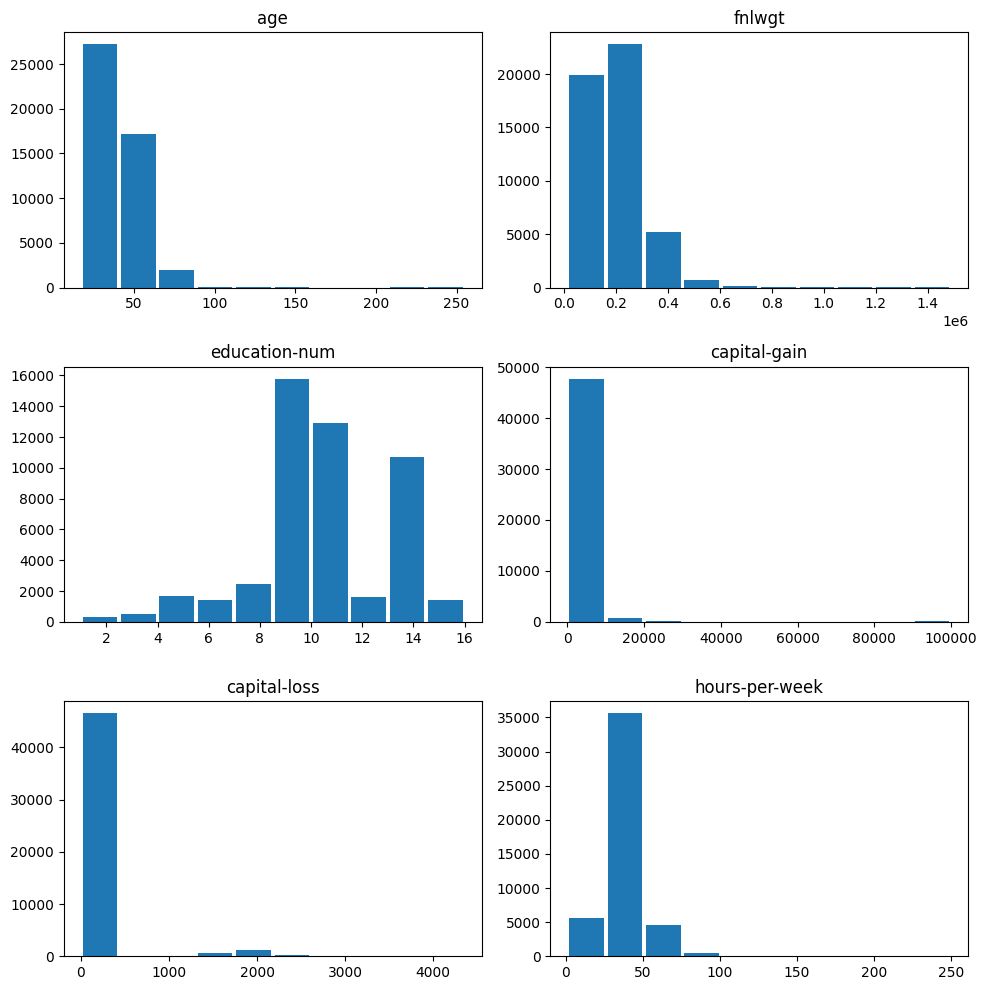

In [15]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(num_cols, 1):
  plt.subplot(3, 2, i)
  plt.hist(data[col], rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
# Columns are skewed and hence null values are replaced using median

data = data.fillna(data[num_cols].median())

In [17]:
data.isna().sum()

,0
age,0
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [18]:
# null Values in numerical cols are removed.
# handling null values in categorical columns
# Using mode to replace null values

In [19]:
data = data.fillna(data[cat_cols].mode().iloc[0])
# .iloc[0] grabs the first mode for each column and returns a Series

In [20]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [21]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,48826.000000
mean,38.597428,1.896605e+05,10.078278,1079.421230,87.530988,40.428481
std,13.602653,1.056025e+05,2.570759,7453.214369,403.067466,12.326046
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [22]:
data.head(2)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K


In [23]:
for col in cat_cols:
  print(data[col].value_counts())
  print()

workclass
Private             35567
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64

education
HS-grad         15780
Some-college    10874
Bachelors        8021
Masters          2657
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              656
Doctorate         594
5th-6th           508
1st-4th           246
Preschool          83
Name: count, dtype: int64

marital-status
Married-civ-spouse       22377
Never-married            16105
Divorced                  6631
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation
Prof-specialty       9208
Craft-repair         5790
Exec-managerial   

In [24]:
for col in cat_cols:
  print(data[col].value_counts(normalize=True) * 100)
  print()

workclass
Private             72.844386
Self-emp-not-inc     7.473477
Local-gov            6.088969
State-gov            3.844263
?                    3.610781
Self-emp-inc         3.326097
Federal-gov          2.756728
Without-pay          0.036866
Never-worked         0.018433
Name: proportion, dtype: float64

education
HS-grad         32.318847
Some-college    22.270921
Bachelors       16.427723
Masters          5.441773
Assoc-voc        4.219064
11th             3.711138
Assoc-acdm       3.278991
10th             2.844796
7th-8th          1.955925
Prof-school      1.708106
9th              1.548355
12th             1.343546
Doctorate        1.216565
5th-6th          1.040429
1st-4th          0.503830
Preschool        0.169991
Name: proportion, dtype: float64

marital-status
Married-civ-spouse       45.830091
Never-married            32.984475
Divorced                 13.580879
Separated                 3.133576
Widowed                   3.108999
Married-spouse-absent     1.286200
M

In [25]:
# workclass, occupation and native country have '?' as entries which has to be handled
# since the % of '?' in these columns is pretty low, dropping the rows as it prevents mode bias
# along with minimal loss of statistical power

In [26]:
data = data.replace('?', np.nan)
data.isna().sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [27]:
data.dropna(inplace = True)

In [28]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [29]:
for col in cat_cols:
  print(data[col].value_counts(normalize=True) * 100)
  print()

workclass
Private             75.559718
Self-emp-not-inc     7.777921
Local-gov            6.344183
State-gov            4.004133
Self-emp-inc         3.407819
Federal-gov          2.863171
Without-pay          0.038750
Never-worked         0.004306
Name: proportion, dtype: float64

education
HS-grad         32.560493
Some-college    22.100232
Bachelors       16.608542
Masters          5.519676
Assoc-voc        4.273228
11th             3.631706
Assoc-acdm       3.319556
10th             2.746922
7th-8th          1.864290
Prof-school      1.724361
9th              1.500474
12th             1.291656
Doctorate        1.203393
5th-6th          0.996728
1st-4th          0.492982
Preschool        0.165763
Name: proportion, dtype: float64

marital-status
Married-civ-spouse       46.239129
Never-married            32.625075
Divorced                 13.790580
Separated                 3.108585
Widowed                   2.910531
Married-spouse-absent     1.250753
Married-AF-spouse         0.075

## Handling Outliers

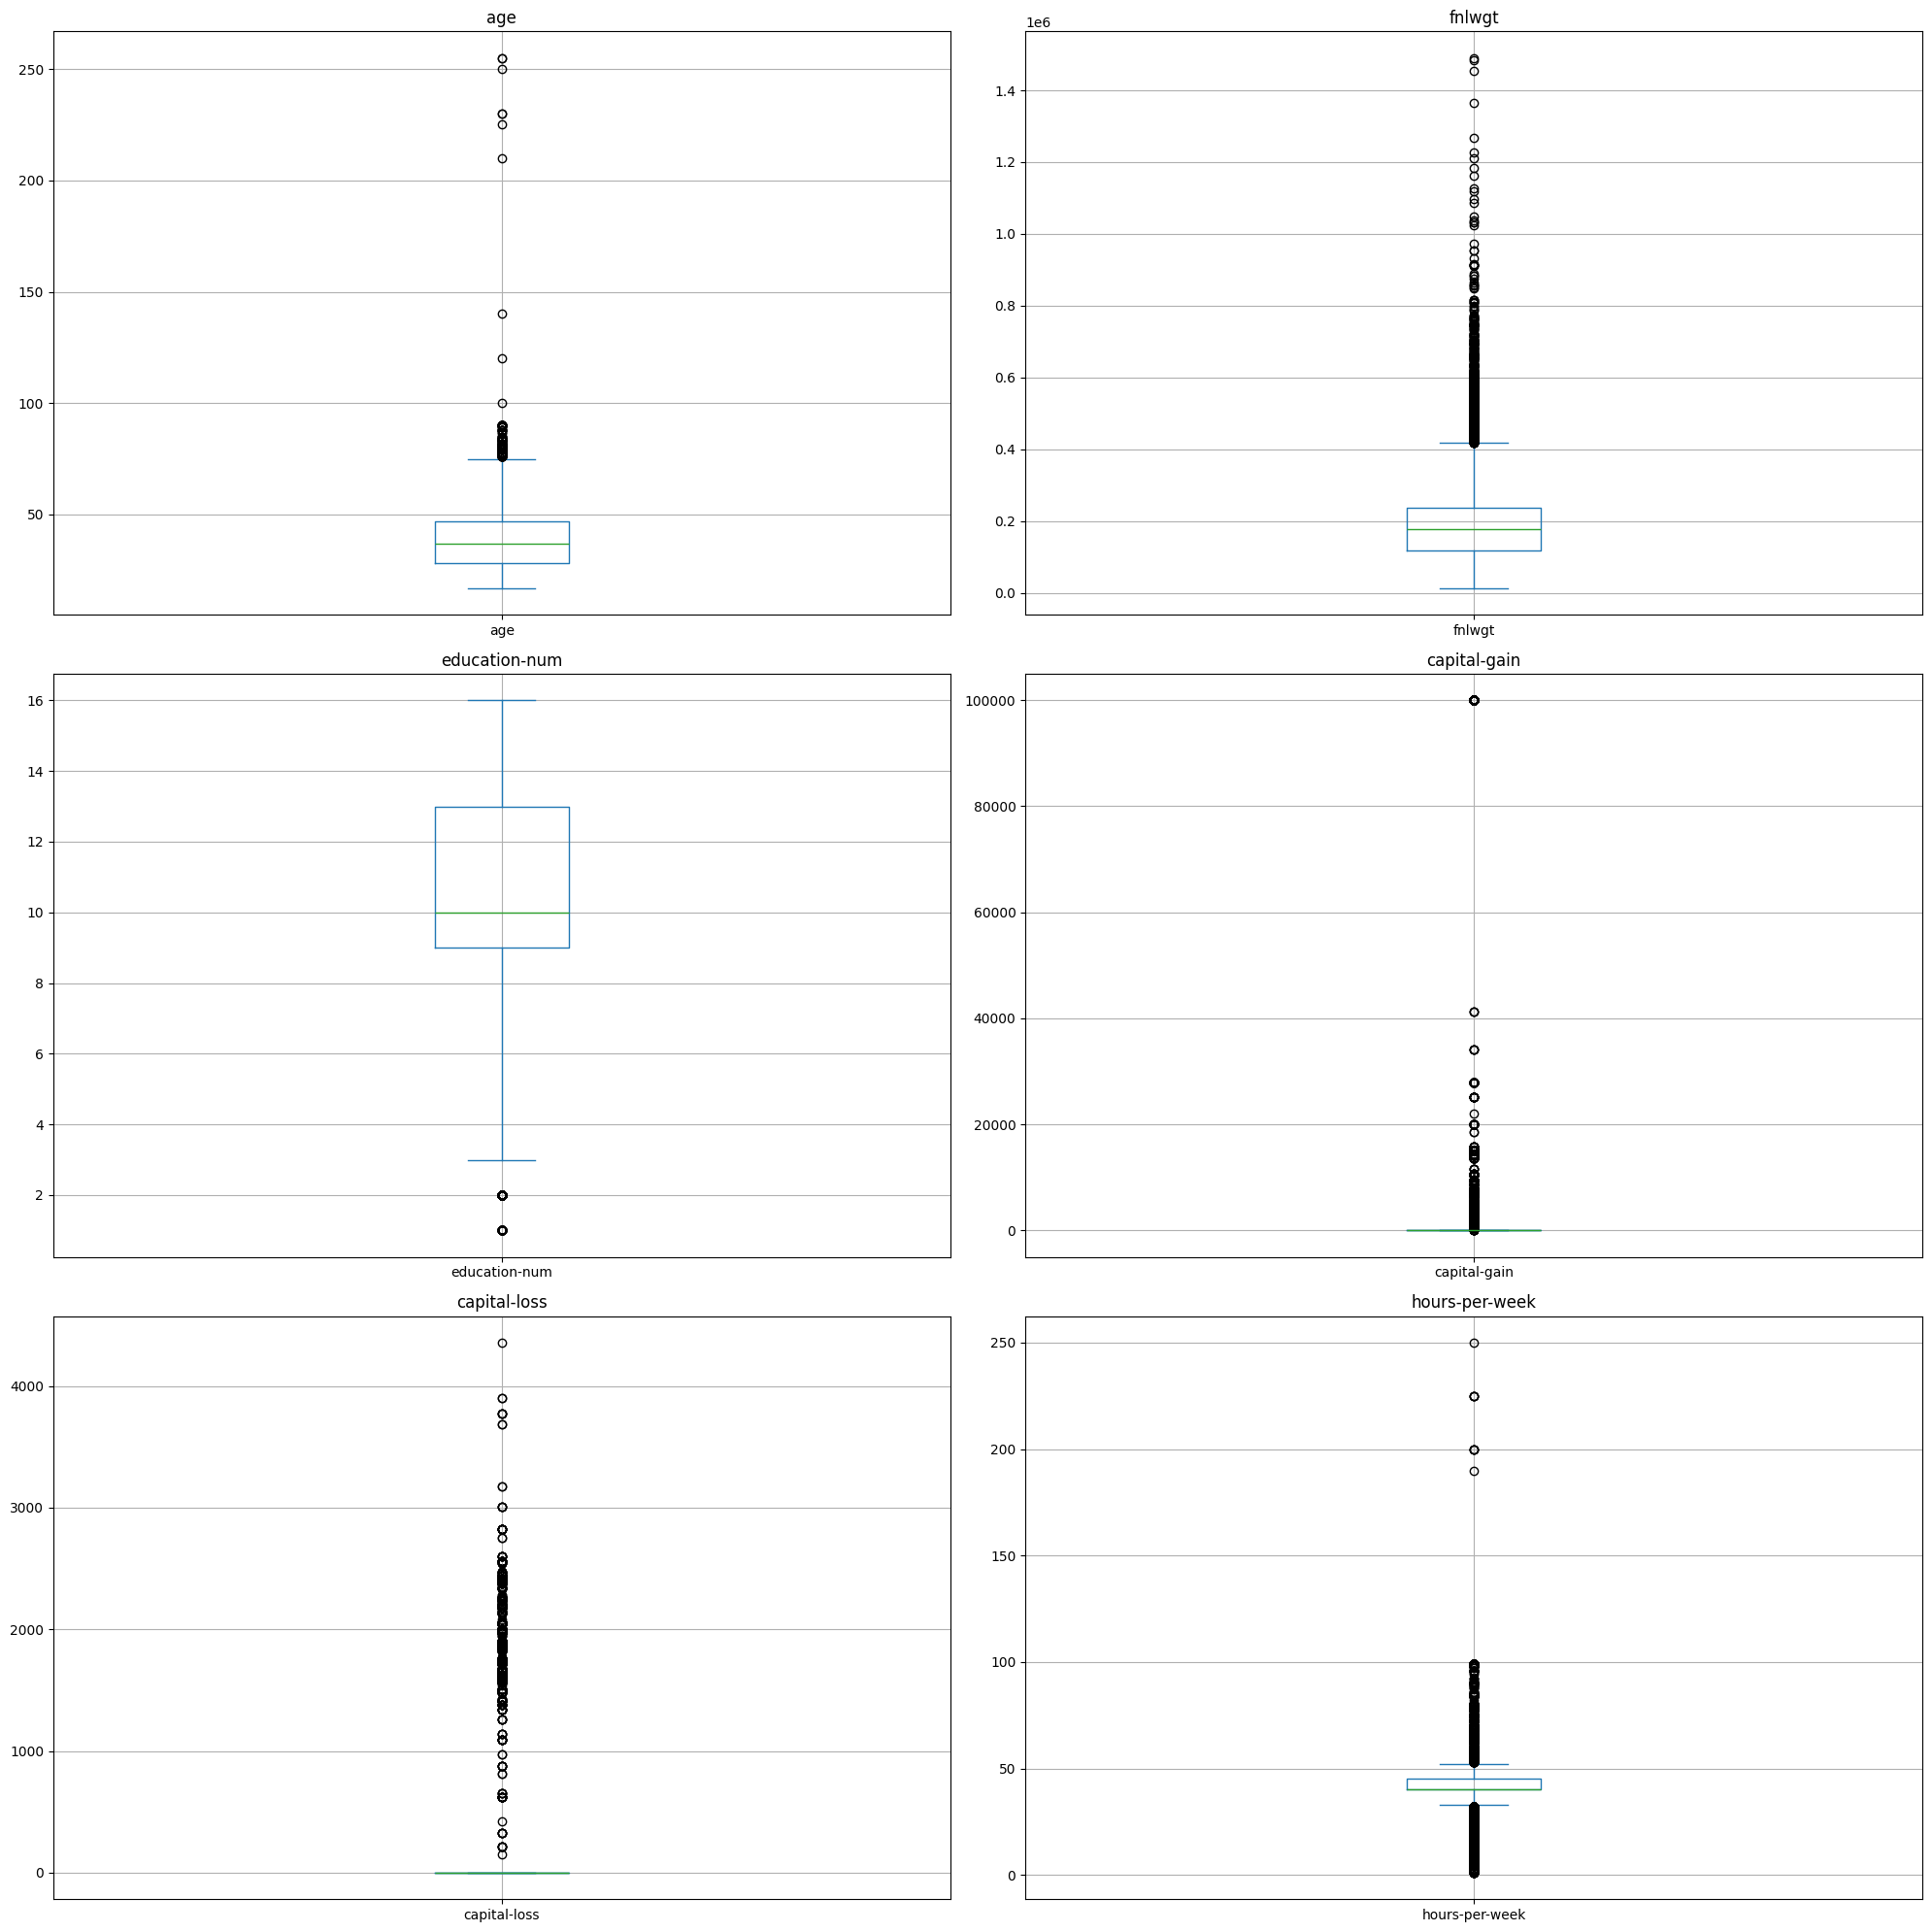

In [30]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols, 1):
  ax = plt.subplot(3, 2, i)
  data[col].plot(kind = 'box', ax = ax)
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [31]:
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((data[num_cols] > upper_limit) | (data[num_cols] < lower_limit)).any(axis = 1)
outliers_df = data[outliers]

outlier_percent = len(outliers_df) / len(data) * 100
print("percentage fo outliers in the dataframe :", outlier_percent)

percentage fo outliers in the dataframe : 37.9574614655989


In [32]:
outlier_counts = ((data[num_cols] > upper_limit) |
                  (data[num_cols] < lower_limit)).mean()*100

print(outlier_counts.sort_values(ascending=False))

hours-per-week    25.482218
capital-gain       8.318264
capital-loss       4.718850
fnlwgt             2.962198
education-num      0.658745
age                0.635064
dtype: float64


In [33]:
# clipping columns age, fnlwgt and education-num since these have very few outliers
cols_to_cap = ['age', 'fnlwgt', 'education-num']
data[cols_to_cap] = data[cols_to_cap].clip(lower_limit, upper_limit, axis=1)

In [34]:
# Applying log transform to capital-gain and capital-loss
# Not ideal to cap these because the difference between a $50,000 gain and a $99,000 gain actually matters for clustering rich people.
# A Log Transform mathematically shrinks the massive gap between $0 and $99,000 turning an exponential curve into a smooth curve.
cols_to_log = ['capital-gain', 'capital-loss']

for col in cols_to_log:
    data[col] = np.log1p(data[col])

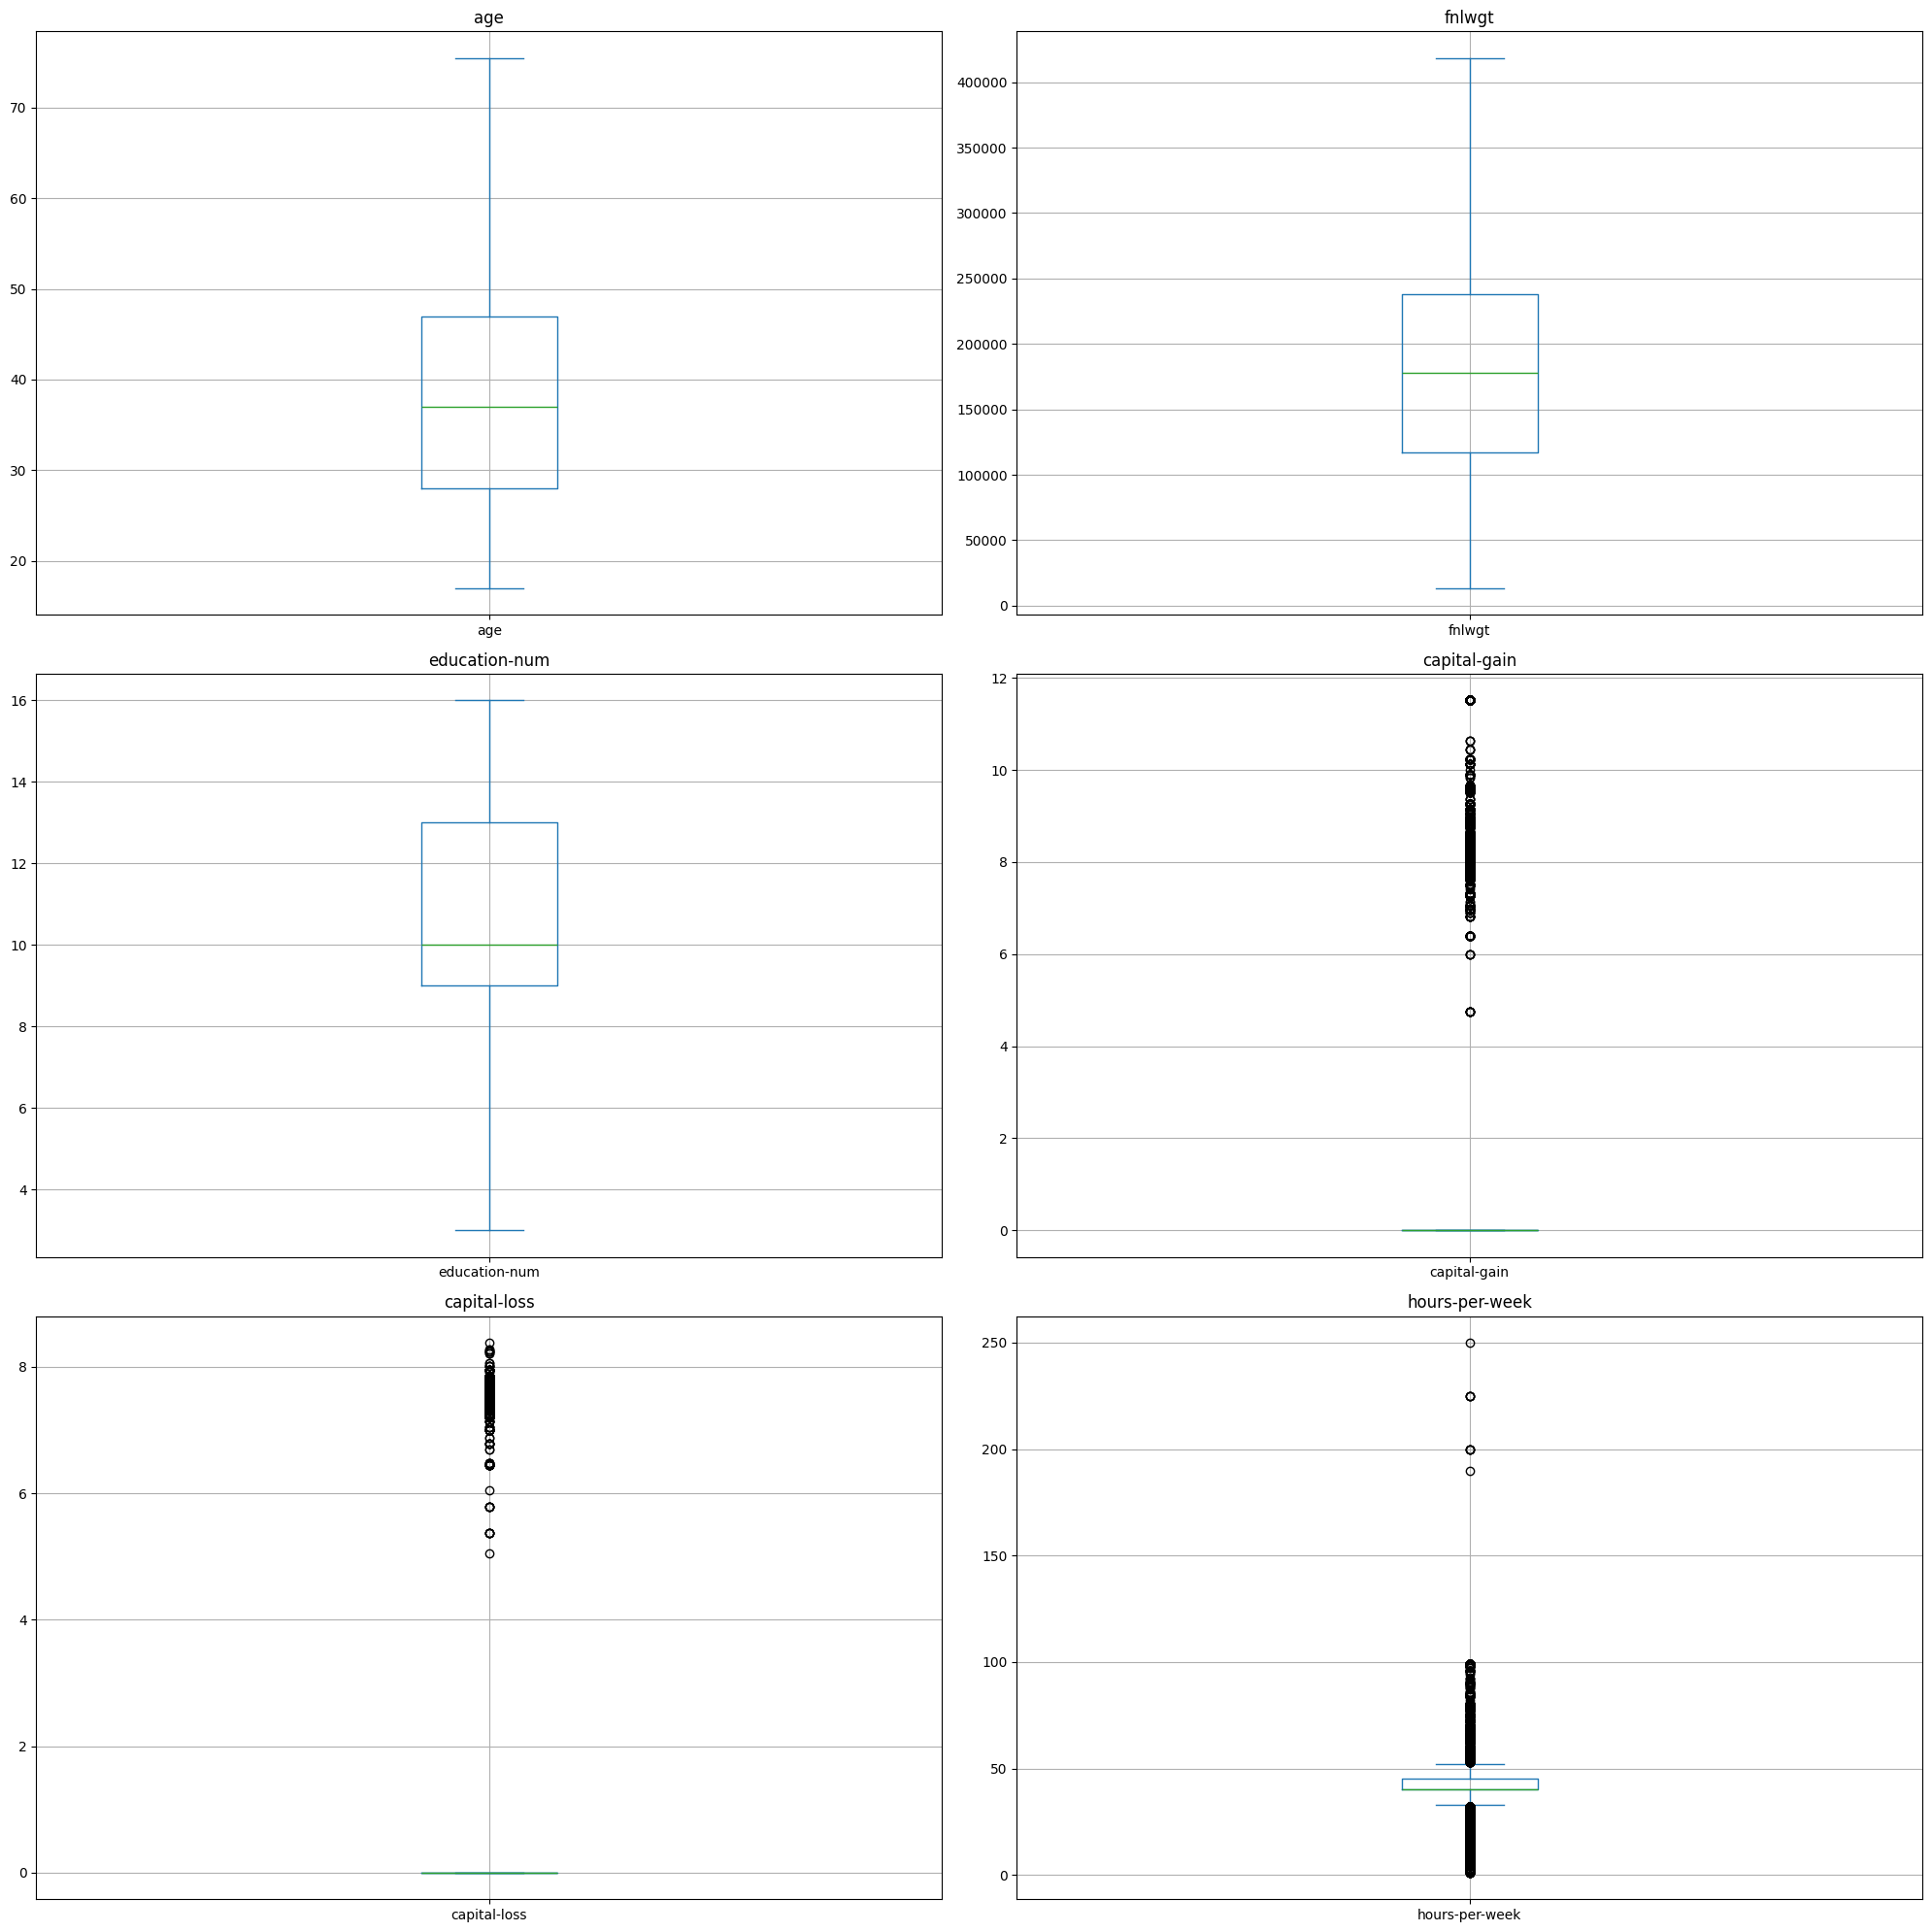

In [35]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols, 1):
  ax = plt.subplot(3, 2, i)
  data[col].plot(kind = 'box', ax = ax)
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [36]:
# Since 250 workhour a week is not possible, capping values where it exceeds '100'
data['hours-per-week'] = np.where(data['hours-per-week'] > 100, np.nan, data['hours-per-week'])

In [37]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [38]:
data.dropna(inplace = True)

In [39]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


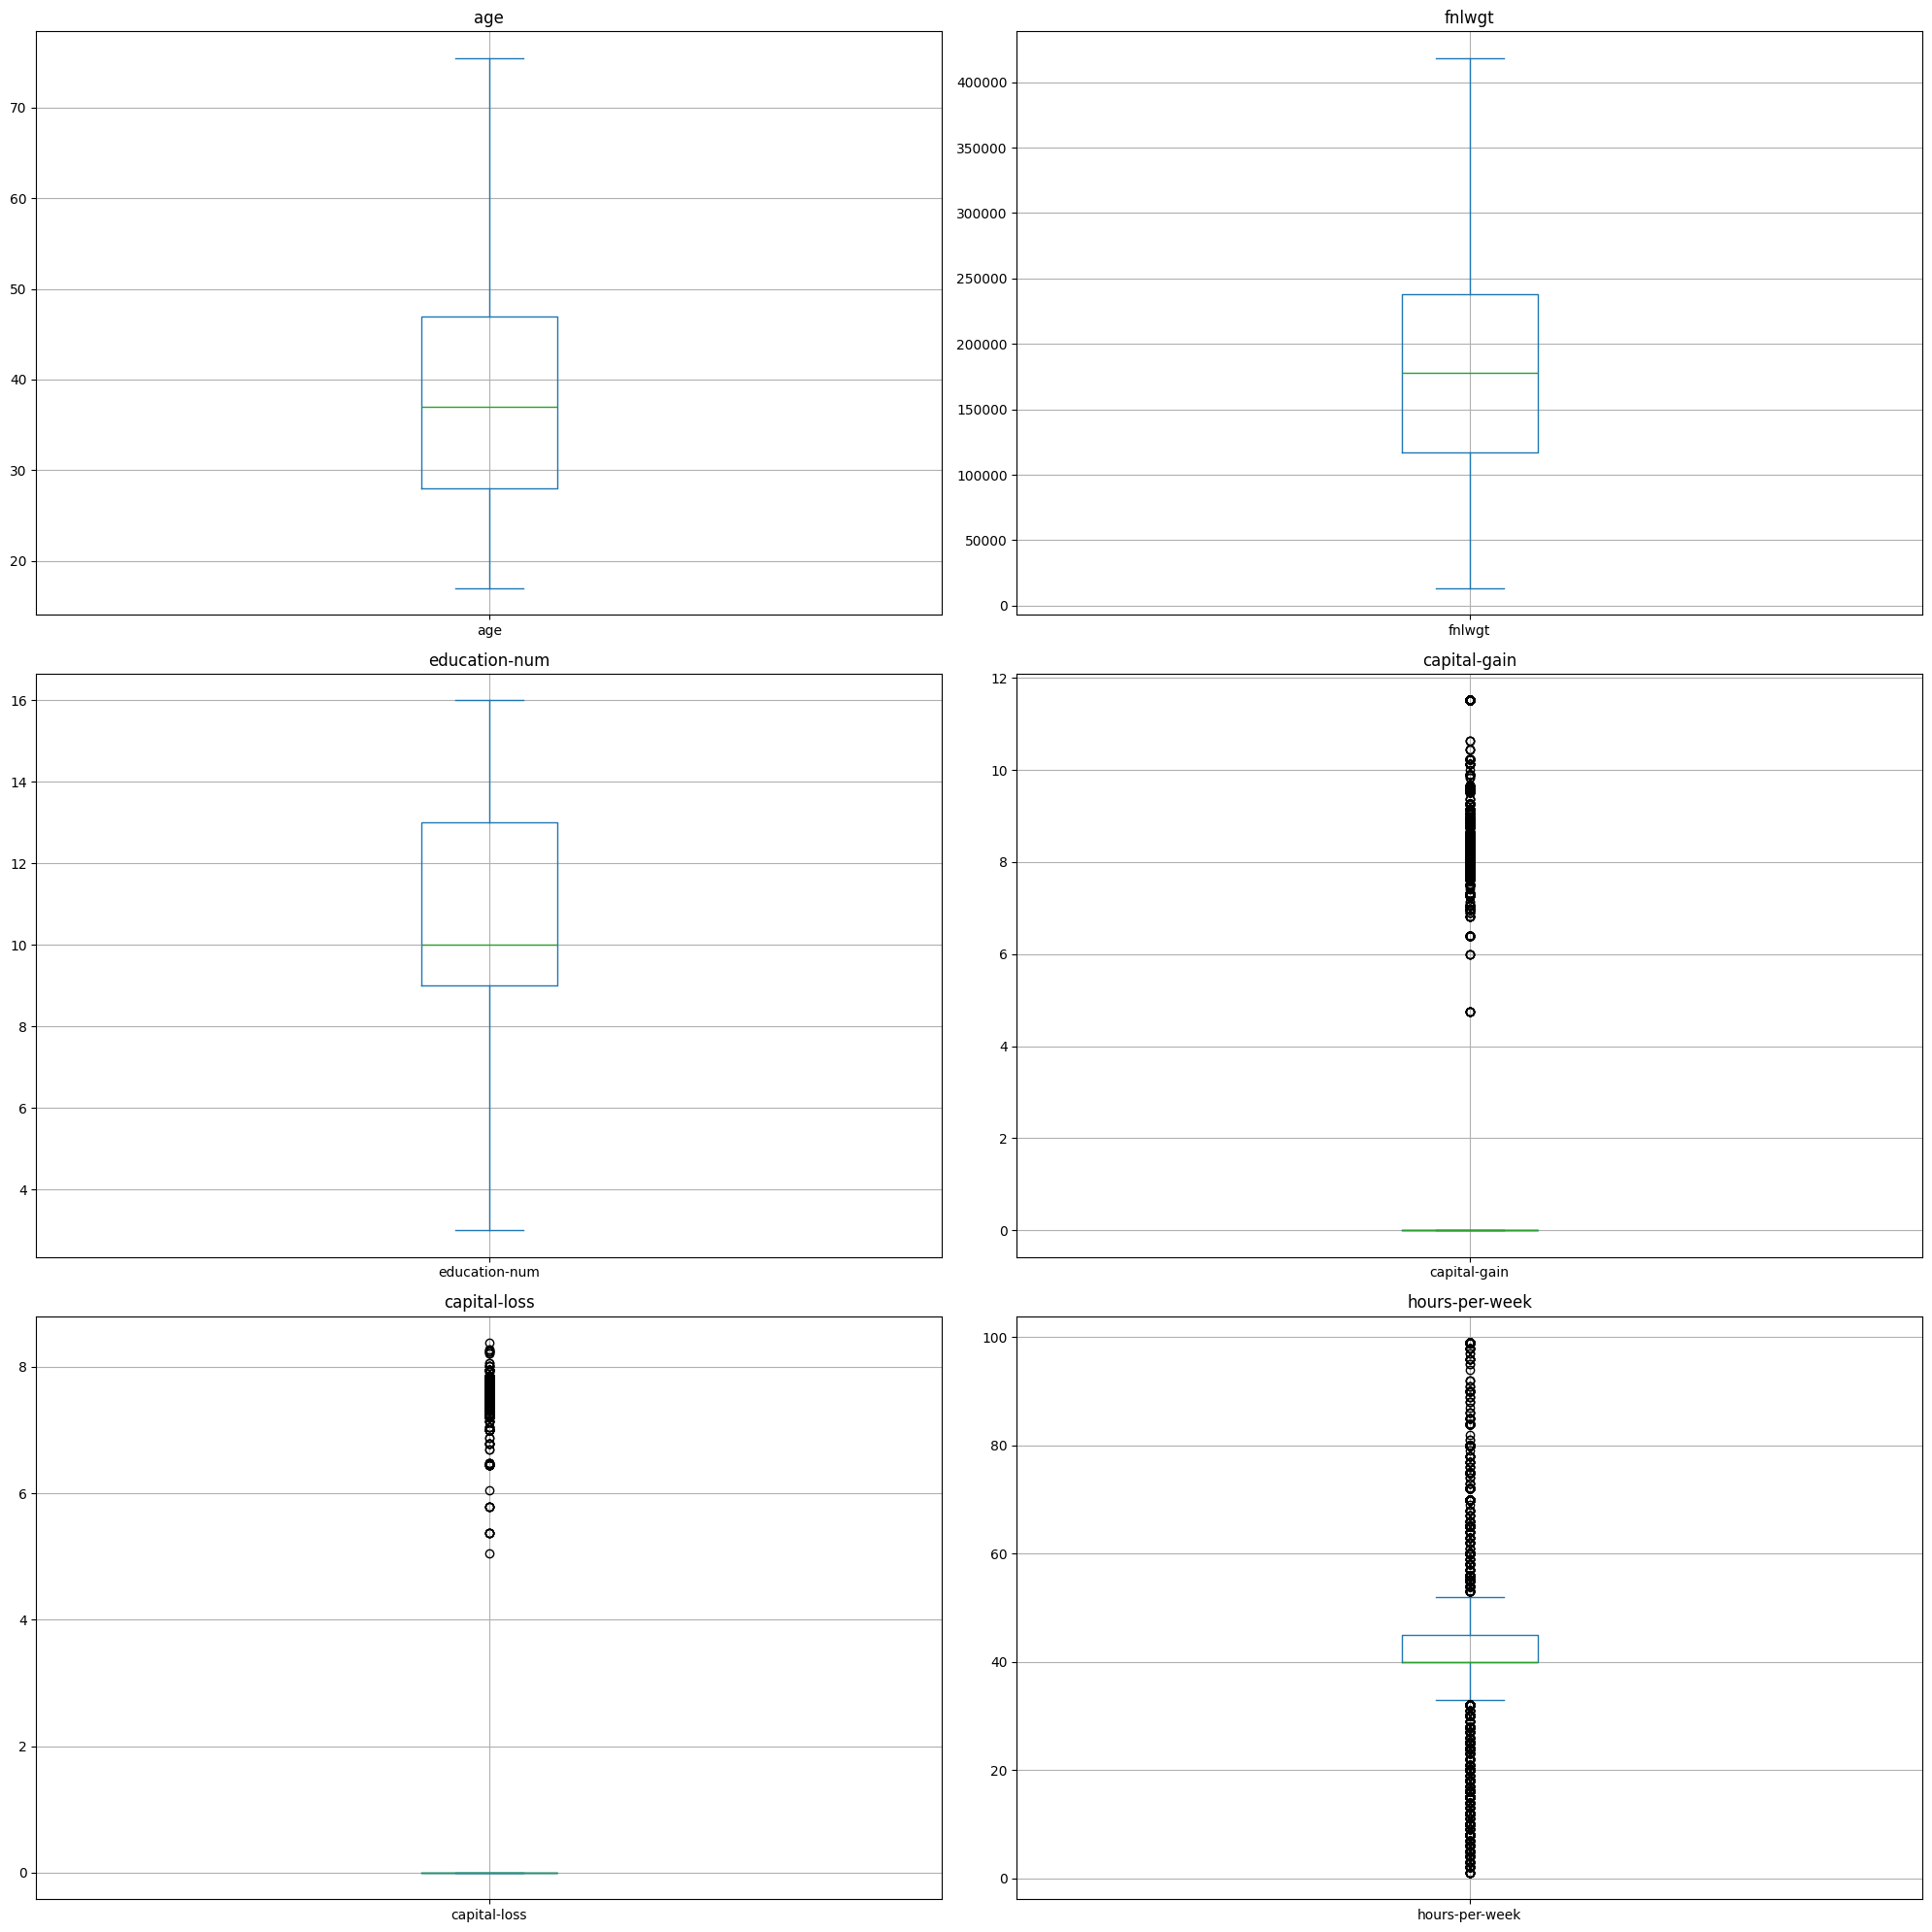

In [40]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols, 1):
  ax = plt.subplot(3, 2, i)
  data[col].plot(kind = 'box', ax = ax)
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

## Removing Unwanted Columns

In [41]:
corr_matrix = data[num_cols].corr(method='pearson')
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.077015,0.036953,0.120115,0.053903,0.088337
fnlwgt,-0.077015,1.000000,-0.038430,-0.007991,-0.001850,-0.013998
education-num,0.036953,-0.038430,1.000000,0.130609,0.078761,0.143096
capital-gain,0.120115,-0.007991,0.130609,1.000000,-0.066522,0.085643
capital-loss,0.053903,-0.001850,0.078761,-0.066522,1.000000,0.047186
hours-per-week,0.088337,-0.013998,0.143096,0.085643,0.047186,1.000000


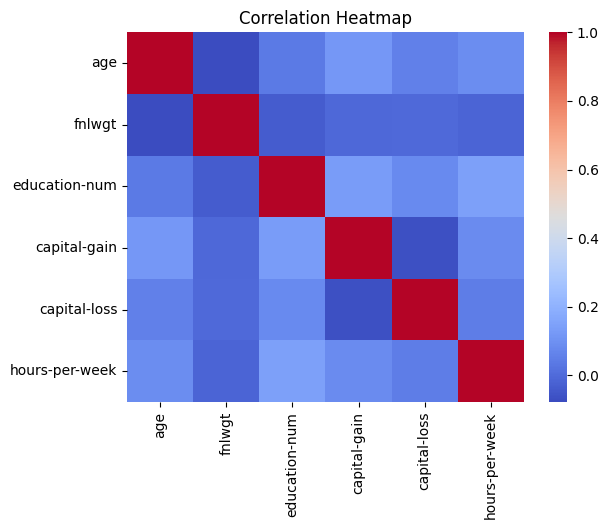

In [42]:
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [43]:
# dropping fnlwgt as it have low correlation
data.drop('fnlwgt', axis = 1, inplace = True)

In [44]:
num_cols = num_cols.drop('fnlwgt')

In [45]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [46]:
data[cat_cols].nunique()

,0
workclass,8
education,16
marital-status,7
occupation,14
relationship,6
race,5
sex,2
native-country,41
income,4


In [47]:
# education and education_nums are essentially same, hence education is removed
data.drop('education', axis = 1, inplace=True)

In [48]:
cat_cols = cat_cols.drop('education')

In [49]:
data.drop('income', axis = 1, inplace = True)
cat_cols = cat_cols.drop('income')

## Scaling

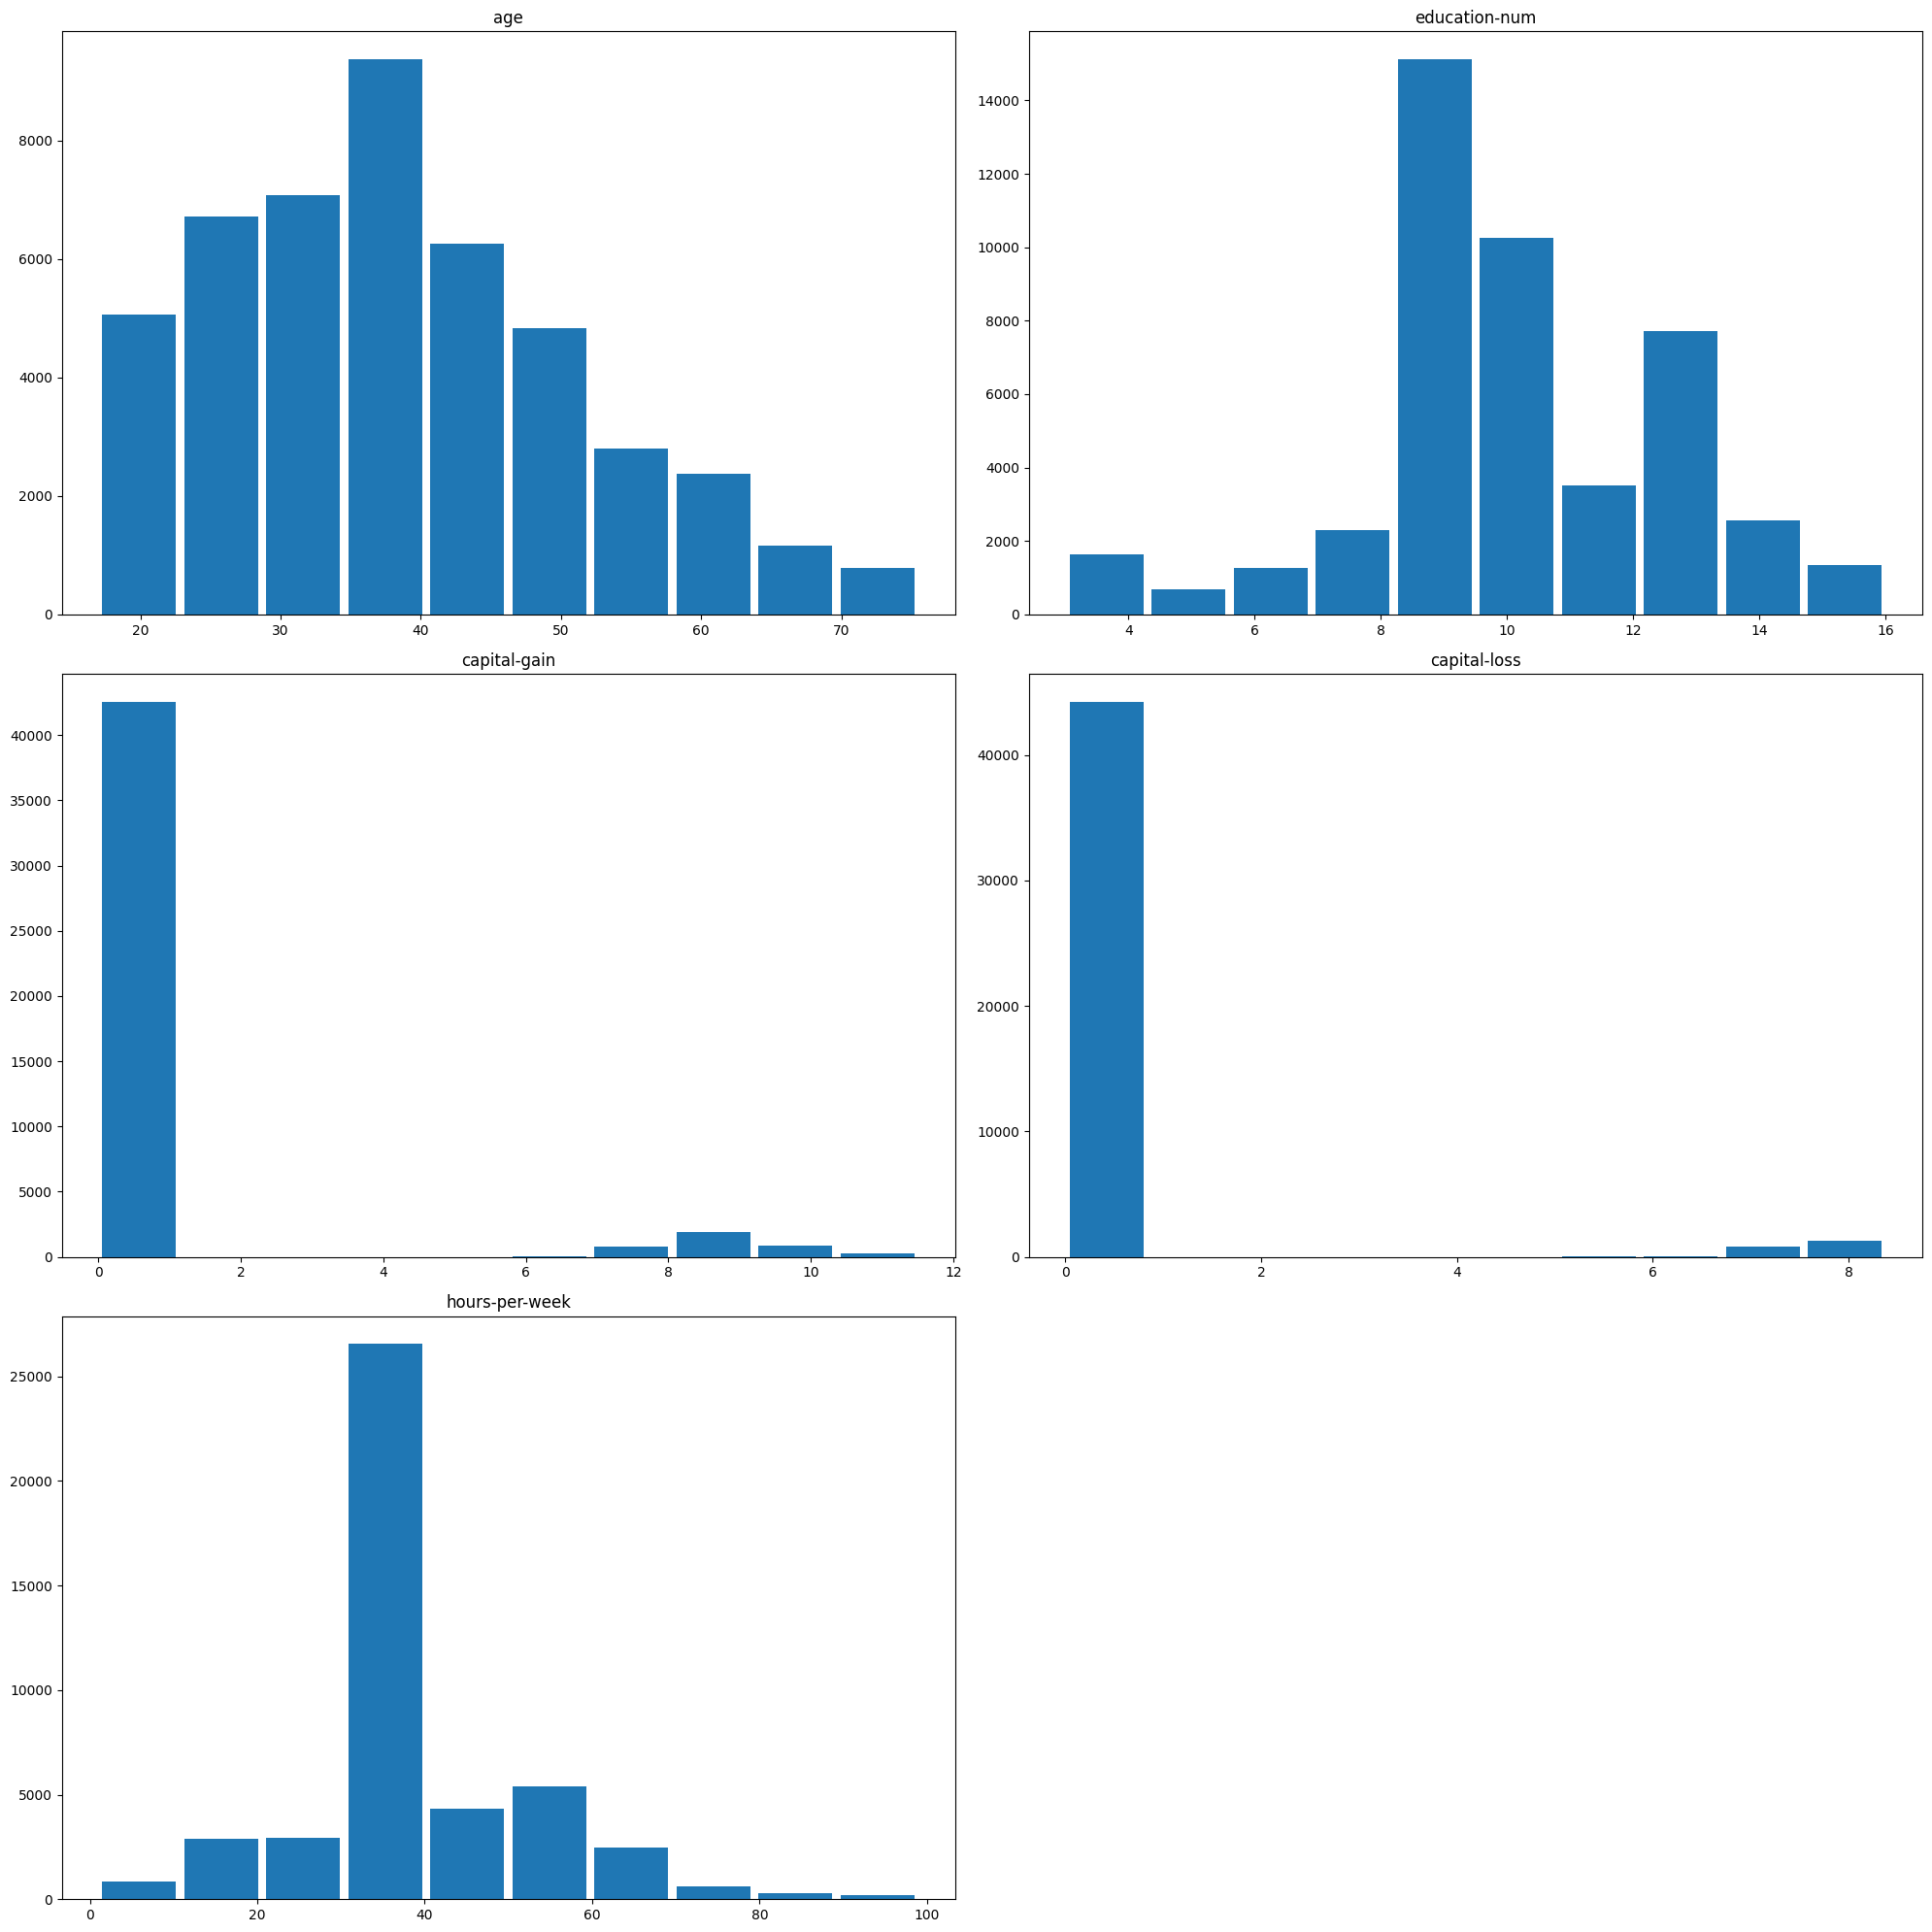

In [50]:
plt.figure(figsize = (20, 20))
for i, col in enumerate(num_cols, 1):
  plt.subplot(3, 2, i)
  plt.hist(data[col], rwidth = 0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [51]:
# Before scaling
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,46442.000000,46442.000000,46442.000000,46442.000000,46442.000000
mean,38.447795,10.113669,0.734704,0.354362,40.692993
std,12.962627,2.530931,2.456286,1.593407,11.843214
min,17.000000,3.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,75.500000,16.000000,11.512925,8.379539,99.000000


In [52]:
scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])

In [53]:
# after scaling
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.644200e+04,4.644200e+04,4.644200e+04,4.644200e+04,4.644200e+04
mean,-2.695785e-16,2.977297e-16,-3.977889e-18,2.968117e-17,7.037803e-17
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-1.654605e+00,-2.810723e+00,-2.991150e-01,-2.223953e-01,-3.351575e+00
25%,-8.060023e-01,-4.400281e-01,-2.991150e-01,-2.223953e-01,-5.851459e-02
50%,-1.116911e-01,-4.491229e-02,-2.991150e-01,-2.223953e-01,-5.851459e-02
75%,6.597657e-01,1.140435e+00,-2.991150e-01,-2.223953e-01,3.636726e-01
max,2.858418e+00,2.325783e+00,4.388063e+00,5.036544e+00,4.923295e+00


In [54]:
# education and education-num are essentially the same

## Grouping values inside cat_cols

In [55]:
data['native-country'].value_counts()

,count
native-country,
United-States,42627
Mexico,876
Philippines,273
Germany,185
Puerto-Rico,169
Canada,157
India,143
El-Salvador,142
Cuba,129


In [56]:
# High-dimensional noise from 40+ binary columns would and degrade clustering performance

In [57]:
data['native-country'] = data['native-country'].str.strip()

In [58]:
data['native-country'] = np.where(data['native-country'] == 'United-States', 'United-States', 'Other')

In [59]:
data[cat_cols].nunique()

,0
workclass,8
marital-status,7
occupation,14
relationship,6
race,5
sex,2
native-country,2


In [60]:
# Grouping Marital status into two to keep dimensions low
data['marital-status'] = data['marital-status'].replace(['Married-civ-spouse','Married-spouse-absent','Married-AF-spouse'], 'Married')
data['marital-status'] = data['marital-status'].replace(['Never-married','Divorced','Separated','Widowed'], 'Single')

In [61]:
data['workclass'].value_counts()

,count
workclass,
Private,35089
Self-emp-not-inc,3613
Local-gov,2947
State-gov,1860
Self-emp-inc,1583
Federal-gov,1330
Without-pay,18
Never-worked,2


In [62]:
data['workclass'] = data['workclass'].str.strip()

workclass_map = {
    'Local-gov': 'Government',
    'State-gov': 'Government',
    'Federal-gov': 'Government',
    'Self-emp-not-inc': 'Self-Employed',
    'Self-emp-inc': 'Self-Employed',
    'Without-pay': 'Other',
    'Never-worked': 'Other'
}

# Apply the mapping
data['workclass'] = data['workclass'].replace(workclass_map)

print(data['workclass'].value_counts())

workclass
Private          35089
Government        6137
Self-Employed     5196
Other               20
Name: count, dtype: int64


## Encoding

In [63]:
data_num = data[num_cols].copy()

cat_encoded = pd.get_dummies(data[cat_cols], drop_first=True, dtype=int)

data = pd.concat([data_num.reset_index(drop=True),
                  cat_encoded.reset_index(drop=True)], axis=1)

print(data.shape)
data.head(3)

(46442, 33)


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Other,workclass_Private,workclass_Self-Employed,marital-status_Single,occupation_Armed-Forces,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_United-States
0,0.042600,1.140435,2.829538,-0.222395,-0.058515,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,1
1,0.891203,1.140435,-0.299115,-0.222395,-2.338326,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1
2,-0.034545,-0.440028,-0.299115,-0.222395,-0.058515,0,1,0,1,0,...,0,0,0,0,0,0,0,1,1,1


# Dimensionality Reduction

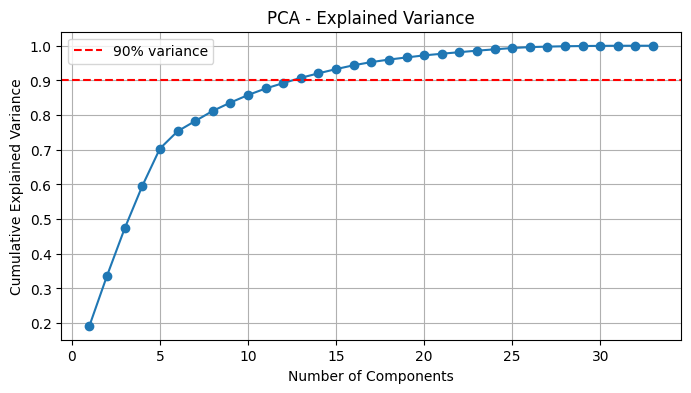

In [64]:
pca = PCA()
pca.fit(data)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.legend()
plt.grid()
plt.show()

In [65]:
pca = PCA(n_components=9)
data_pca = pca.fit_transform(data)

print("Shape after PCA:", data_pca.shape)

Shape after PCA: (46442, 9)


## KMeans

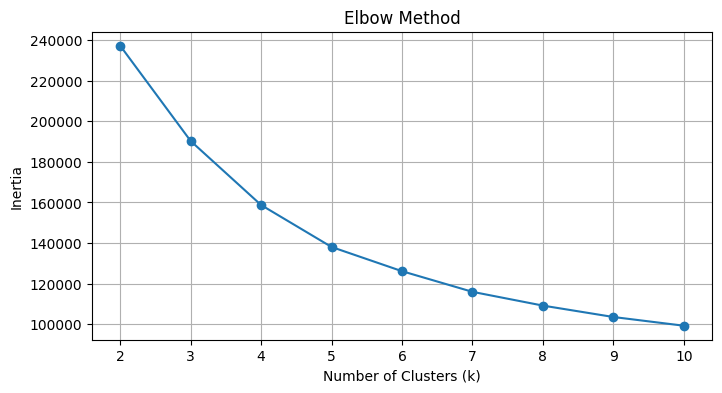

In [66]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid()
plt.show()

k=2, silhouette score: 0.3715
k=3, silhouette score: 0.4195
k=4, silhouette score: 0.2171
k=5, silhouette score: 0.2224
k=6, silhouette score: 0.2235
k=7, silhouette score: 0.2277
k=8, silhouette score: 0.2269
k=9, silhouette score: 0.2022
k=10, silhouette score: 0.2099


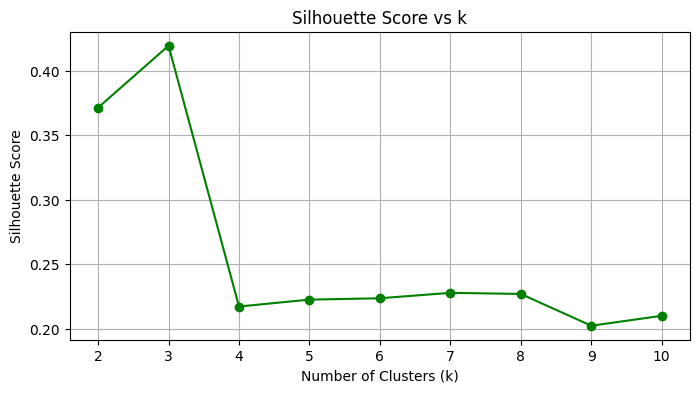

In [67]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_pca)
    score = silhouette_score(data_pca, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f"k={k}, silhouette score: {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.grid()
plt.show()

In [68]:
best_k = 3

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = km_final.fit_predict(data_pca)

print("KMeans cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

KMeans cluster counts:
0    40395
1     3856
2     2191
Name: count, dtype: int64


## Agglomerative Clustering

In [70]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

# Sample 5000 rows
sample_idx = np.random.choice(len(data_pca), size=5000)
data_pca_sample = data_pca[sample_idx]

agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels_sample = agg.fit_predict(data_pca_sample)

print("Agglomerative cluster counts (on 5000 sample):")
print(pd.Series(agg_labels_sample).value_counts().sort_index())

Agglomerative cluster counts (on 5000 sample):
0    4346
1     439
2     215
Name: count, dtype: int64


## Graphs

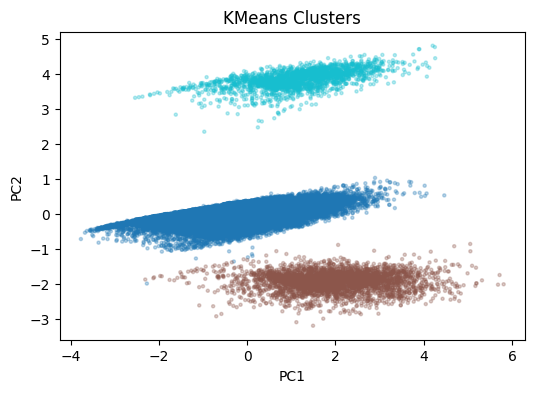

In [76]:
plt.figure(figsize=(6, 4))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.3, s=5)
plt.title('KMeans Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

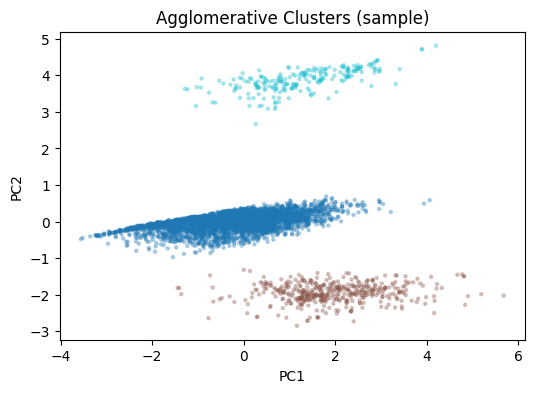

In [77]:
plt.figure(figsize=(6, 4))
plt.scatter(data_pca_sample[:, 0], data_pca_sample[:, 1], c=agg_labels_sample, cmap='tab10', alpha=0.3, s=5)
plt.title('Agglomerative Clusters (sample)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [72]:
km_sil = silhouette_score(data_pca, kmeans_labels, sample_size=5000, random_state=42)
agg_sil = silhouette_score(data_pca_sample, agg_labels_sample)

print(f"KMeans Silhouette Score        : {km_sil:.4f}")
print(f"Agglomerative Silhouette Score : {agg_sil:.4f}")

KMeans Silhouette Score        : 0.4195
Agglomerative Silhouette Score : 0.4258


In [73]:
profile_df = data.copy()
profile_df['cluster'] = kmeans_labels

# Mean of each feature per cluster
cluster_profile = profile_df.groupby('cluster').mean().T
print(cluster_profile)

cluster                              0         1         2
age                          -0.049756  0.385324  0.239197
education-num                -0.056327  0.390678  0.350925
capital-gain                 -0.298716  3.299270 -0.299115
capital-loss                 -0.222395 -0.222395  4.491654
hours-per-week               -0.035666  0.254819  0.209095
workclass_Other               0.000421  0.000519  0.000456
workclass_Private             0.765119  0.689315  0.695573
workclass_Self-Employed       0.104320  0.168309  0.151985
marital-status_Single         0.551850  0.323651  0.369694
occupation_Armed-Forces       0.000322  0.000259  0.000456
occupation_Craft-repair       0.124743  0.114886  0.110908
occupation_Exec-managerial    0.111821  0.196577  0.194432
occupation_Farming-fishing    0.031613  0.026193  0.020539
occupation_Handlers-cleaners  0.045080  0.022562  0.021908
occupation_Machine-op-inspct  0.063498  0.045643  0.043359
occupation_Other-service      0.106993  0.040716  0.0447

In [75]:
for cluster_id in range(best_k):
    print(f"Cluster {cluster_id}")
    subset = profile_df[profile_df['cluster'] == cluster_id]
    print(f"  Size         : {len(subset)}")
    print(f"  Avg Age      : {subset['age'].mean():.2f}  (scaled)")
    print(f"  Avg Edu-num  : {subset['education-num'].mean():.2f}  (scaled)")
    print(f"  Avg Hours/wk : {subset['hours-per-week'].mean():.2f}  (scaled)")
    print(f"  Avg Cap-gain : {subset['capital-gain'].mean():.2f}  (scaled)")

Cluster 0
  Size         : 40395
  Avg Age      : -0.05  (scaled)
  Avg Edu-num  : -0.06  (scaled)
  Avg Hours/wk : -0.04  (scaled)
  Avg Cap-gain : -0.30  (scaled)
Cluster 1
  Size         : 3856
  Avg Age      : 0.39  (scaled)
  Avg Edu-num  : 0.39  (scaled)
  Avg Hours/wk : 0.25  (scaled)
  Avg Cap-gain : 3.30  (scaled)
Cluster 2
  Size         : 2191
  Avg Age      : 0.24  (scaled)
  Avg Edu-num  : 0.35  (scaled)
  Avg Hours/wk : 0.21  (scaled)
  Avg Cap-gain : -0.30  (scaled)
